# Plot M-Variation (Fig. 3) — AUROC, AURAC, Accuracy

Meng-convert m_variation_summary.csv menjadi grafik.

## 1. Muat data

Pakai summary kalau ada; kalau tidak, agregasi otomatis dari raw.

In [3]:
import pandas as pd
from pathlib import Path

def load_summary():
    if Path("../results/m_variation/m_variation_summary.csv").exists():
        return pd.read_csv("../results/m_variation/m_variation_summary.csv")
    if Path("../results/m_variation/m_variation_raw.csv").exists():
        print("summary tak ada -> agregasi dari raw")
        raw = pd.read_csv("../results/m_variation/m_variation_raw.csv")
        raw["auroc_num"] = pd.to_numeric(raw["auroc"], errors="coerce")
        g = raw.groupby("M")
        return pd.DataFrame({
            "M": sorted(raw["M"].unique()),
            "auroc_mean": g["auroc_num"].mean().values,
            "aurac_mean": pd.to_numeric(raw["aurac"], errors="coerce").groupby(raw["M"]).mean().values,
            "accuracy_mean": g["accuracy"].mean().values,
        })
    raise FileNotFoundError("CSV tidak ditemukan.")

df = load_summary().sort_values("M")
df

,M,auroc_mean,auroc_std,aurac_mean,accuracy_mean,latency_mean_s
0,3,0.5404,0.1453,0.1160,0.2083,2.406
1,5,0.5391,0.1639,0.1431,0.2083,4.004
2,7,0.5453,0.1704,0.1522,0.2083,5.601
3,10,0.5711,0.1499,0.1662,0.2083,7.995


## 3. Buat grafik (AUROC, AURAC, Accuracy)

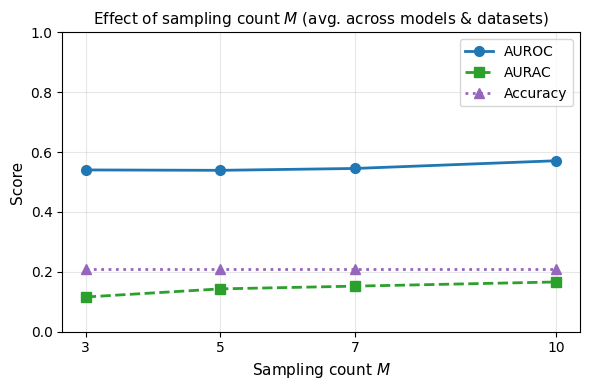

Tersimpan: fig_m_variation.pdf & .png


In [6]:
import matplotlib.pyplot as plt

def col(df,*names):
    for n in names:
        if n in df.columns: return df[n]
    raise KeyError(names)

M        = col(df,"M")
auroc    = col(df,"auroc_mean","auroc")
aurac    = col(df,"aurac_mean","aurac")
accuracy = col(df,"accuracy_mean","accuracy")

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(M, auroc,    "o-",  label="AUROC",    color="#1f77b4", linewidth=2, markersize=7)
ax.plot(M, aurac,    "s--", label="AURAC",    color="#2ca02c", linewidth=2, markersize=7)
ax.plot(M, accuracy, "^:",  label="Accuracy", color="#9467bd", linewidth=2, markersize=7)
ax.set_xlabel("Sampling count $M$", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_xticks(list(M)); ax.set_ylim(0,1); ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=10, frameon=True)
ax.set_title("Effect of sampling count $M$ (avg. across models & datasets)", fontsize=11)
fig.tight_layout()
fig.savefig("../results/figures/fig_m_variation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Tersimpan: fig_m_variation.pdf & .png")